# EDA — Superstore Sales Dataset

Análisis exploratorio del dataset `superstore.csv`.

- 9.994 registros de pedidos de una tienda online de EE. UU.
- 4 años de datos (2015–2018)
- 21 columnas: fechas, identificadores, datos geográficos, categorías de producto y las 4 métricas de negocio (`Sales`, `Quantity`, `Discount`, `Profit`).
- Fuente: https://github.com/leonism/sample-superstore

## Carga de datos

El CSV tiene tres peculiaridades que hay que gestionar en la carga:

1. Las últimas 806 filas no son ventas — son tablas auxiliares (People, Returns) que se pegaron al final del archivo. Se detectan porque tienen `Sales` nulo; las filtramos.
2. `Postal Code` viene como número decimal (float), con los ceros iniciales comidos. Lo reconstruimos a texto de 5 dígitos.
3. Las fechas vienen en formato americano `m/d/yyyy`.

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('superstore.csv')

# 1. Filtramos las filas basura (tablas auxiliares al final)
df = df[df['Sales'].notna()].copy()

# 2. Postal Code: de float a texto con 5 dígitos (rellenando ceros iniciales)
df['Postal Code'] = df['Postal Code'].apply(
    lambda x: str(int(x)).zfill(5) if pd.notna(x) else np.nan
)

# 3. Fechas en formato americano
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

# 4. Quantity como entero (viene como float por el parseo)
df['Quantity'] = df['Quantity'].astype(int)

print('=' * 60)
print('EXPLORACIÓN COMPLETA — superstore.csv (21 columnas)')
print('=' * 60)

EXPLORACIÓN COMPLETA — superstore.csv (21 columnas)


## 1. Dimensiones del dataset

In [34]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 9,994
Columnas: 21


## 2. Primeras y últimas filas

In [35]:
print('PRIMERAS 5 FILAS:')
print(df.head())

print('\nÚLTIMAS 5 FILAS:')
print(df.tail())

PRIMERAS 5 FILAS:
  Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0      1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1      2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2      3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3      4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4      5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code Region       Product ID         Category Sub-Category  \
0       42420  South 

## 3. Estructura y tipos de columnas

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   str           
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9983 non-null   str           
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## 4. Estadísticas descriptivas y clasificación de variables

Antes de entrar en estadísticas, clasificamos cada columna según su tipo analítico. Esta clasificación guía el resto del análisis: qué estadísticos tiene sentido calcular, qué gráficos usar y qué agrupaciones son válidas.

**Identificadores y ruido:**
- `Row ID` — numérica continua (identificador secuencial, sin valor analítico).
- `Order ID` — categórica nominal (identificador de pedido; útil para contar pedidos únicos).
- `Country` — categórica nominal (valor constante "United States", sin poder discriminativo).

**Temporales:**
- `Order Date` — temporal (datetime). Fecha del pedido, base de la evolución y la estacionalidad.
- `Ship Date` — temporal (datetime). Fecha de envío, base de `Dias Envio`.

**Categóricas ordinales:**
- `Ship Mode` — categórica ordinal. Orden: Same Day < First Class < Second Class < Standard Class (velocidad de entrega).

**Categóricas nominales:**
- `Customer ID` y `Customer Name` — identificadores de cliente (793 valores únicos).
- `Segment` — tipo de cliente: Consumer, Corporate, Home Office.
- `City` (531), `State` (49), `Postal Code` (630) y `Region` (4) — granularidad geográfica.
- `Product ID` (1.862), `Category` (3), `Sub-Category` (17) y `Product Name` (1.850) — jerarquía de producto.

**Numéricas continuas:**
- `Sales` — importe facturado por línea.
- `Quantity` — unidades vendidas por línea (sin tope teórico).
- `Profit` — beneficio por línea (positivo o negativo).

**Numéricas discretas:**
- `Discount` — política comercial cerrada: solo 12 valores posibles entre 0 y 0,80.

`describe()` a continuación muestra estadísticas solo de las numéricas (las categóricas se analizan en la sección 6).

In [37]:
print(df.describe())

                       Order Date                   Ship Date         Sales  \
count                        9994                        9994   9994.000000   
mean   2017-04-30 05:17:08.056834  2017-05-04 04:17:20.304182    229.858001   
min           2015-01-03 00:00:00         2015-01-07 00:00:00      0.444000   
25%           2016-05-23 00:00:00         2016-05-27 00:00:00     17.280000   
50%           2017-06-26 00:00:00         2017-06-29 00:00:00     54.490000   
75%           2018-05-14 00:00:00         2018-05-18 00:00:00    209.940000   
max           2018-12-30 00:00:00         2019-01-05 00:00:00  22638.480000   
std                           NaN                         NaN    623.245101   

          Quantity     Discount       Profit  
count  9994.000000  9994.000000  9994.000000  
mean      3.789574     0.156203    28.656896  
min       1.000000     0.000000 -6599.978000  
25%       2.000000     0.000000     1.728750  
50%       3.000000     0.200000     8.666500  
75%   

## 5. Valores nulos por columna

Después de filtrar las filas basura (las 806 que correspondían a las tablas auxiliares People y Returns), solo quedan 11 nulos reales en `Postal Code`, que corresponden a 11 ciudades donde faltaba ese dato en el CSV.

In [38]:
nulos = df.isnull().sum()
pct = (df.isnull().mean() * 100).round(2)
resumen = pd.DataFrame({'nulos': nulos, '%': pct})
print(resumen.to_string())

               nulos     %
Row ID             0  0.00
Order ID           0  0.00
Order Date         0  0.00
Ship Date          0  0.00
Ship Mode          0  0.00
Customer ID        0  0.00
Customer Name      0  0.00
Segment            0  0.00
Country            0  0.00
City               0  0.00
State              0  0.00
Postal Code       11  0.11
Region             0  0.00
Product ID         0  0.00
Category           0  0.00
Sub-Category       0  0.00
Product Name       0  0.00
Sales              0  0.00
Quantity           0  0.00
Discount           0  0.00
Profit             0  0.00


## 6. Análisis columna por columna

Para cada columna mostramos tipo, nulos, valores únicos y — según sea numérica o categórica — estadísticas o top 10 valores más frecuentes.

In [39]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(f"  Tipo: {df[col].dtype}")
    print(f"  Nulos: {df[col].isnull().sum():,} ({df[col].isnull().mean()*100:.1f}%)")
    print(f"  Valores únicos: {df[col].nunique():,}")

    if df[col].dtype in ['int64', 'float64']:
        print(f"  Min: {df[col].min()}  |  Max: {df[col].max()}")
        print(f"  Media: {df[col].mean():.2f}  |  Mediana: {df[col].median():.2f}")
        print(f"  Desv. estándar: {df[col].std():.2f}")
    else:
        top10 = df[col].value_counts().head(10)
        print(f"  Top 10 valores:")
        for val, cnt in top10.items():
            print(f"    {val}: {cnt:,} ({cnt/len(df)*100:.1f}%)")


--- Row ID ---
  Tipo: str
  Nulos: 0 (0.0%)
  Valores únicos: 9,994
  Top 10 valores:
    1: 1 (0.0%)
    2: 1 (0.0%)
    3: 1 (0.0%)
    4: 1 (0.0%)
    5: 1 (0.0%)
    6: 1 (0.0%)
    7: 1 (0.0%)
    8: 1 (0.0%)
    9: 1 (0.0%)
    10: 1 (0.0%)

--- Order ID ---
  Tipo: str
  Nulos: 0 (0.0%)
  Valores únicos: 5,009
  Top 10 valores:
    CA-2018-100111: 14 (0.1%)
    CA-2018-157987: 12 (0.1%)
    US-2017-108504: 11 (0.1%)
    CA-2017-165330: 11 (0.1%)
    CA-2016-131338: 10 (0.1%)
    US-2016-126977: 10 (0.1%)
    CA-2017-105732: 10 (0.1%)
    CA-2018-117457: 9 (0.1%)
    CA-2015-106439: 9 (0.1%)
    CA-2016-164882: 9 (0.1%)

--- Order Date ---
  Tipo: datetime64[us]
  Nulos: 0 (0.0%)
  Valores únicos: 1,236
  Top 10 valores:
    2017-09-05 00:00:00: 38 (0.4%)
    2018-09-02 00:00:00: 36 (0.4%)
    2017-11-10 00:00:00: 35 (0.4%)
    2018-12-01 00:00:00: 34 (0.3%)
    2018-12-02 00:00:00: 34 (0.3%)
    2018-12-09 00:00:00: 33 (0.3%)
    2018-11-12 00:00:00: 30 (0.3%)
    2018-12-08 0

## 7. Matriz de correlaciones

Correlación entre las 4 variables numéricas de negocio (`Sales`, `Quantity`, `Discount`, `Profit`). Nos interesa sobre todo ver cómo `Discount` se relaciona con `Profit` y si `Sales` correlaciona con `Quantity`.

In [40]:
cols_corr = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluimos Row ID porque es un identificador y su correlación no tiene sentido
cols_corr = [c for c in cols_corr if c != 'Row ID']
print(df[cols_corr].corr().round(2).to_string())

          Sales  Quantity  Discount  Profit
Sales      1.00      0.20     -0.03    0.48
Quantity   0.20      1.00      0.01    0.07
Discount  -0.03      0.01      1.00   -0.22
Profit     0.48      0.07     -0.22    1.00


### 7.1 Heatmap de correlaciones

La misma matriz anterior en formato visual: azul cuando la correlación es positiva, rojo cuando es negativa, más intenso cuanto más cerca del ±1. Se lee de un vistazo y resalta los pares de variables que se mueven juntas o en direcciones opuestas.

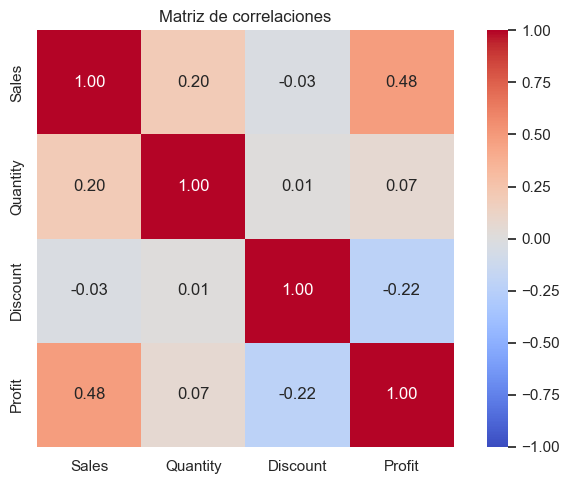

In [41]:
plt
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[cols_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title('Matriz de correlaciones')
plt.tight_layout()
plt.show()

### 7.2 Matriz de correlaciones ampliada (con get_dummies)

Sobre las 4 numéricas + dummies de las categóricas con pocos niveles.

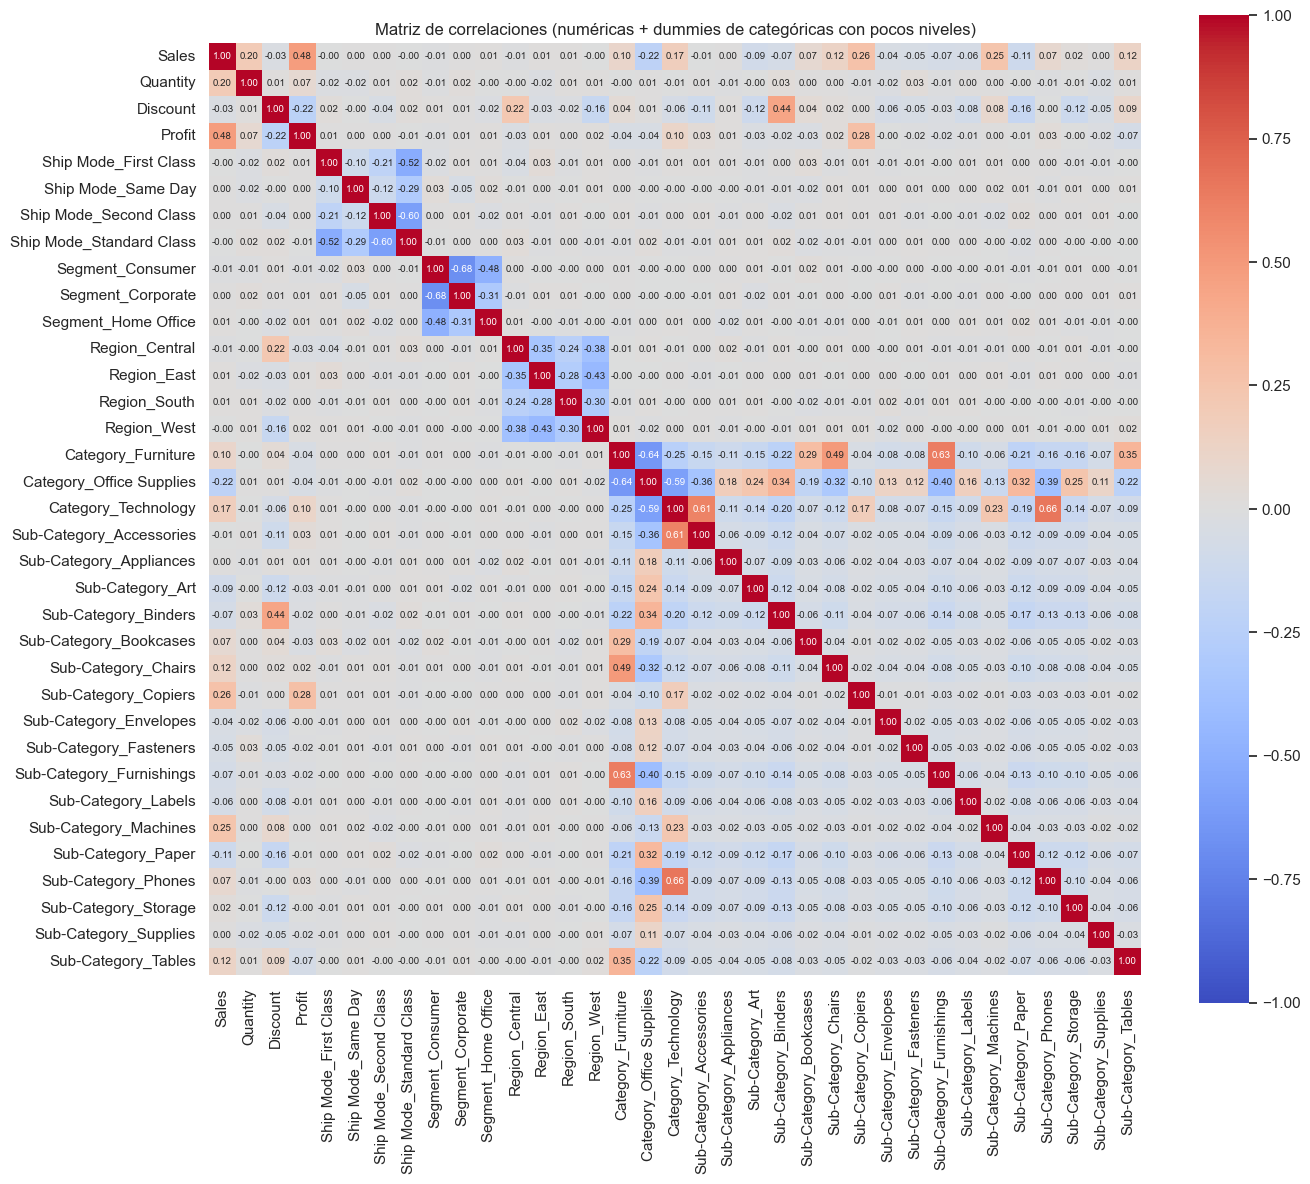

In [42]:
cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

df_dummies = pd.get_dummies(df[cat_cols], drop_first=False)
df_for_corr = pd.concat([df[num_cols], df_dummies], axis=1)

plt.figure(figsize=(14, 12))
sns.heatmap(
    df_for_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    annot_kws={'size': 7}
)
plt.title('Matriz de correlaciones (numéricas + dummies de categóricas con pocos niveles)')
plt.tight_layout()
plt.show()

## Limpieza final y conversión de tipos

- Eliminamos las 11 filas con Postal Code nulo (0,11 % del total).
- Convertimos Postal Code a tipo `category` (más eficiente en memoria y conceptualmente correcto).

In [43]:
df = df.dropna(subset=['Postal Code'])
df['Postal Code'] = df['Postal Code'].astype('category')

df.info()

<class 'pandas.DataFrame'>
Index: 9983 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9983 non-null   str           
 1   Order ID       9983 non-null   str           
 2   Order Date     9983 non-null   datetime64[us]
 3   Ship Date      9983 non-null   datetime64[us]
 4   Ship Mode      9983 non-null   str           
 5   Customer ID    9983 non-null   str           
 6   Customer Name  9983 non-null   str           
 7   Segment        9983 non-null   str           
 8   Country        9983 non-null   str           
 9   City           9983 non-null   str           
 10  State          9983 non-null   str           
 11  Postal Code    9983 non-null   category      
 12  Region         9983 non-null   str           
 13  Product ID     9983 non-null   str           
 14  Category       9983 non-null   str           
 15  Sub-Category   9983 non-null   str   

## 8. Análisis de fechas y variables derivadas

Creamos métricas de negocio que no vienen explícitas en el CSV:

- **ventas_mensuales** — suma de Sales por mes.
- **ventas_anuales** — suma de Sales por año.
- **pedidos_anuales** — número de pedidos únicos (Order IDs distintos) por año. Clave: un mismo pedido puede aparecer en varias filas si tiene varios productos.
- **ticket_medio_anual** = ventas_anuales / pedidos_anuales. Cuánto gasta un cliente de media en cada compra.
- **Dias Envio** — diferencia en días entre Ship Date y Order Date.

In [44]:
ventas_mensuales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
ventas_anuales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()
pedidos_anuales = df.groupby(df['Order Date'].dt.year)['Order ID'].nunique()
ticket_medio_anual = ventas_anuales / pedidos_anuales

df['Dias Envio'] = (df['Ship Date'] - df['Order Date']).dt.days

print('VENTAS MENSUALES:')
print(ventas_mensuales)
print('\nVENTAS ANUALES:')
print(ventas_anuales)
print('\nPEDIDOS ÚNICOS ANUALES:')
print(pedidos_anuales)
print('\nTICKET MEDIO ANUAL:')
print(ticket_medio_anual.round(2))
print('\nDÍAS DE ENVÍO — estadísticas:')
print(df['Dias Envio'].describe().round(2))

VENTAS MENSUALES:
Order Date
2015-01     14236.8950
2015-02      4519.8920
2015-03     55691.0090
2015-04     28295.3450
2015-05     23648.2870
2015-06     34595.1276
2015-07     33946.3930
2015-08     27909.4685
2015-09     81777.3508
2015-10     31453.3930
2015-11     78628.7167
2015-12     69545.6205
2016-01     18174.0756
2016-02     11951.4110
2016-03     38726.2520
2016-04     34195.2085
2016-05     30131.6865
2016-06     24797.2920
2016-07     28765.3250
2016-08     36898.3322
2016-09     64595.9180
2016-10     31404.9235
2016-11     70852.4635
2016-12     74919.5212
2017-01     16870.1810
2017-02     22978.8150
2017-03     51715.8750
2017-04     37455.2890
2017-05     56987.7280
2017-06     40344.5340
2017-07     39261.9630
2017-08     31115.3743
2017-09     73410.0249
2017-10     59687.7450
2017-11     79411.9658
2017-12     96999.0430
2018-01     43334.1940
2018-02     20301.1334
2018-03     58872.3528
2018-04     36521.5361
2018-05     44261.1102
2018-06     52981.7257
2018-

## 9. Visualizaciones

Elegimos el gráfico según el tipo de variable:

- Categórica con pocos valores (≤ 20) → countplot
- Categórica con muchos valores → barplot del top N
- Numérica muy sesgada → histograma en escala log
- Temporal (fechas) → lineplot agrupado por mes/año
- Numérica cruzada con categórica → boxplot
- Dos numéricas → scatterplot

In [45]:
sns.set_theme(style='whitegrid', palette='deep')

### 9.1 Categóricas con pocos niveles → countplot

`Ship Mode` es la única categórica ordinal del grupo, así que la graficamos aparte con su orden natural (de más rápido a más lento) en lugar de ordenarla por frecuencia.

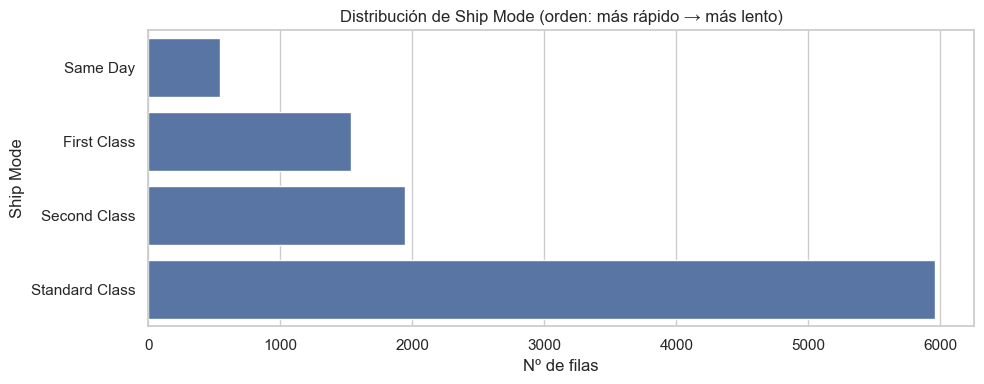

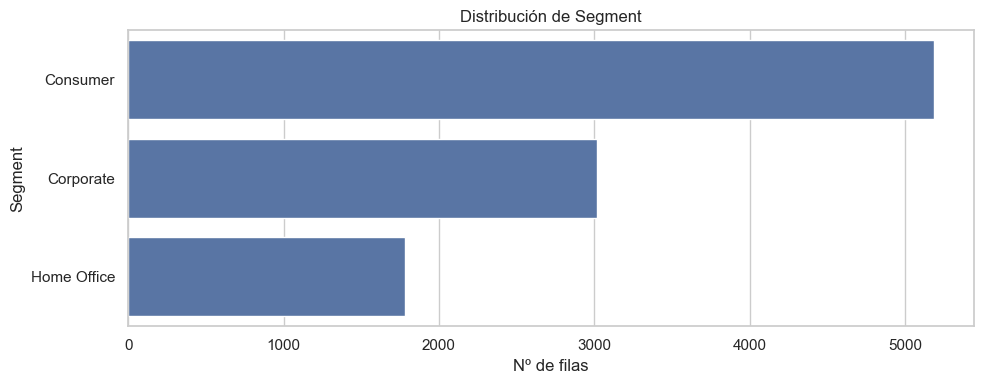

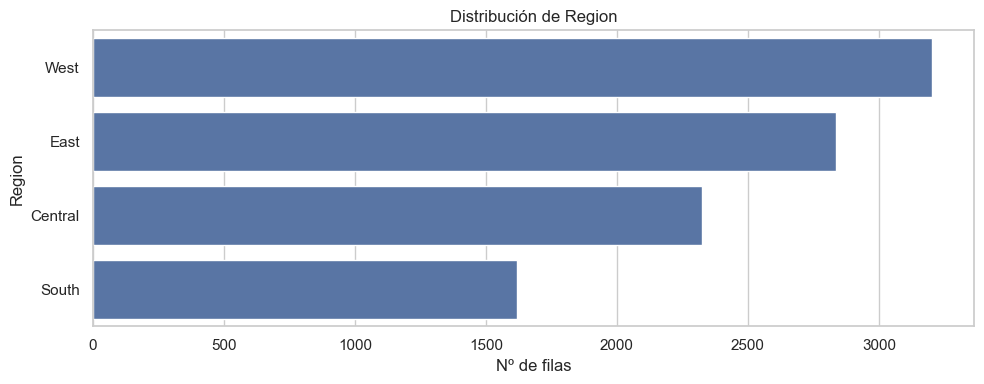

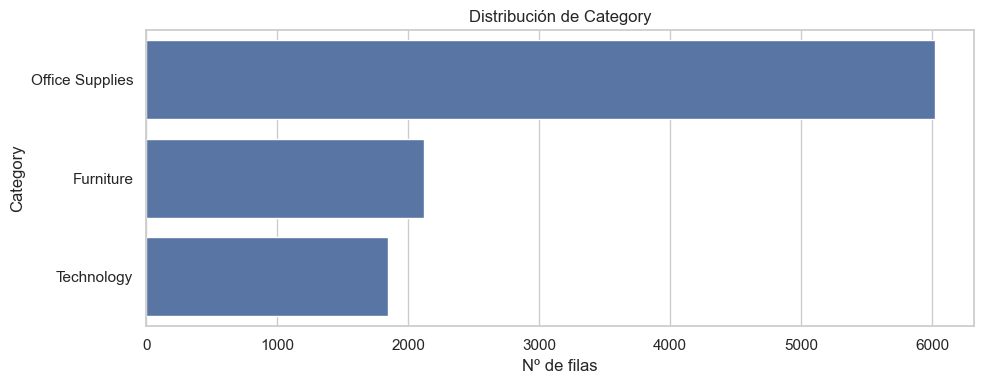

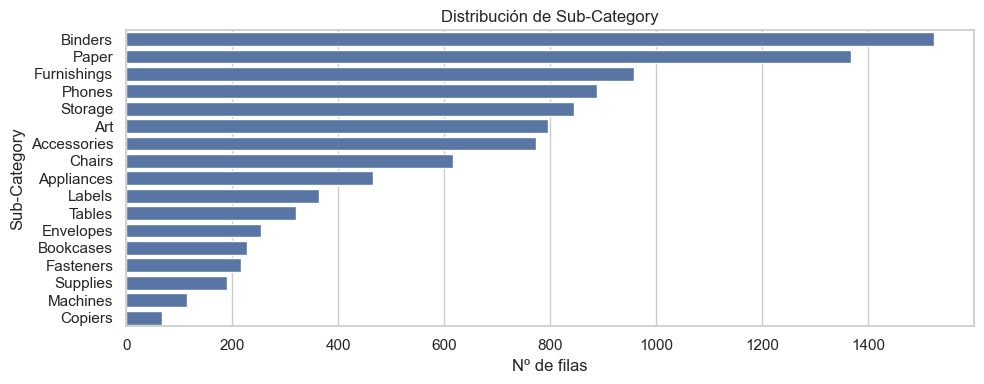

In [46]:
# Ship Mode — categórica ordinal: ordenada por velocidad de entrega
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df, y='Ship Mode',
    order=['Same Day', 'First Class', 'Second Class', 'Standard Class']
)
plt.title('Distribución de Ship Mode (orden: más rápido → más lento)')
plt.xlabel('Nº de filas')
plt.tight_layout()
plt.show()

# Resto — categóricas nominales: ordenadas por frecuencia
cat_pocas = ['Segment', 'Region', 'Category', 'Sub-Category']

for col in cat_pocas:
    plt.figure(figsize=(10, 4))
    orden = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=orden)
    plt.title(f'Distribución de {col}')
    plt.xlabel('Nº de filas')
    plt.tight_layout()
    plt.show()

### 9.2 Categóricas con muchos niveles → top 15

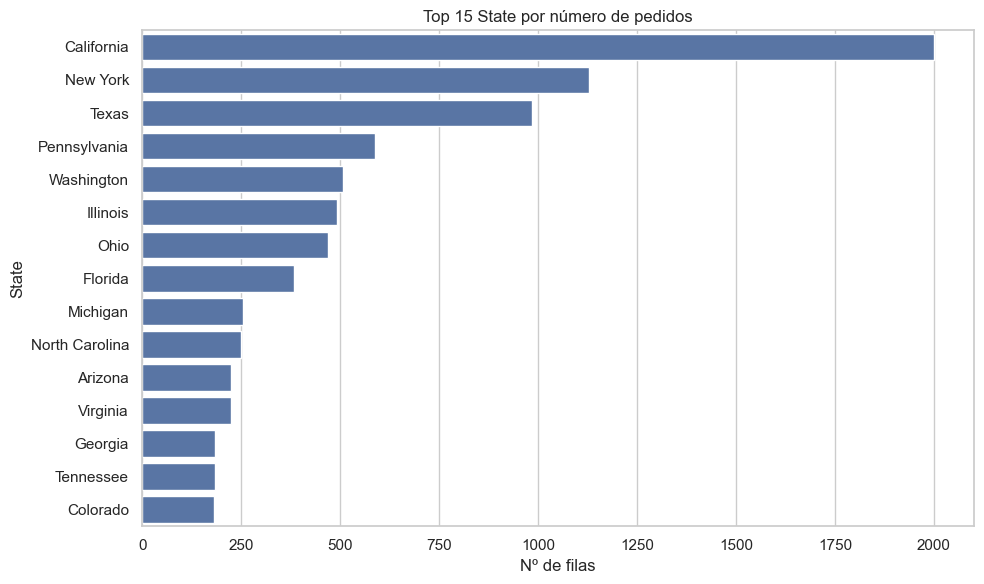

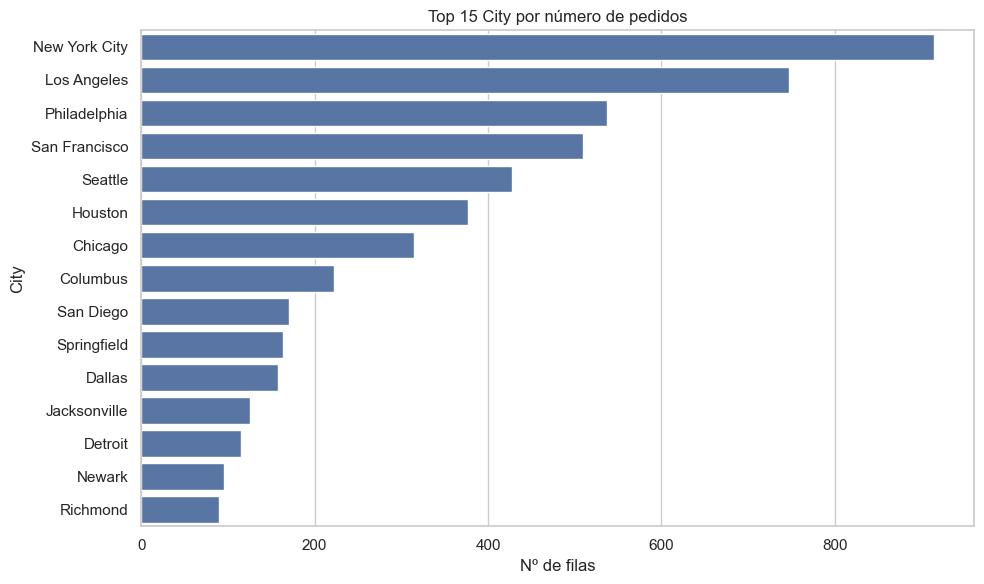

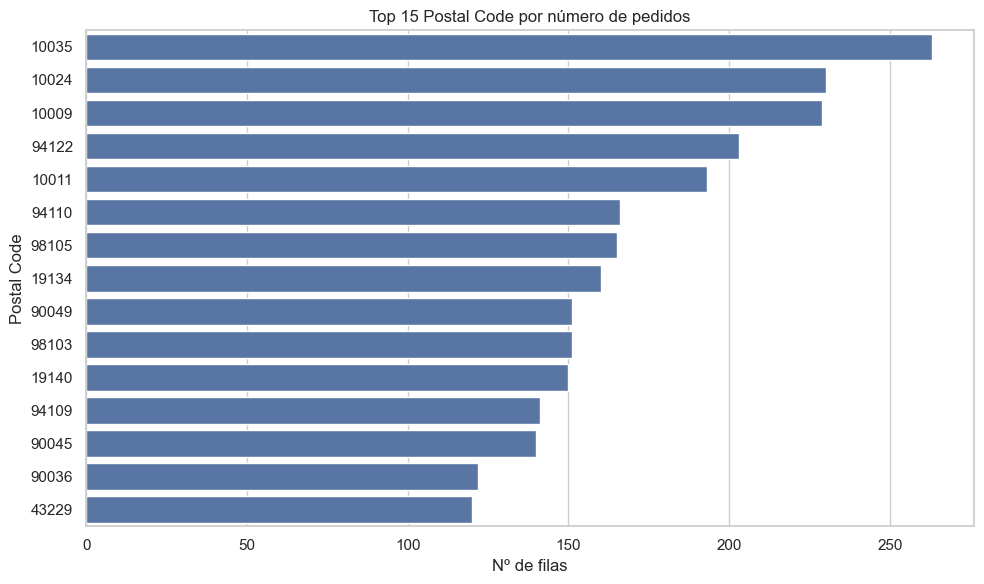

In [47]:
for col, top_n in [('State', 15), ('City', 15), ('Postal Code', 15)]:
    plt.figure(figsize=(10, 6))
    top = df[col].value_counts().head(top_n)
    sns.barplot(x=top.values, y=top.index.astype(str))
    plt.title(f'Top {top_n} {col} por número de pedidos')
    plt.xlabel('Nº de filas')
    plt.tight_layout()
    plt.show()

### 9.3 Distribución de Sales → histograma en escala log

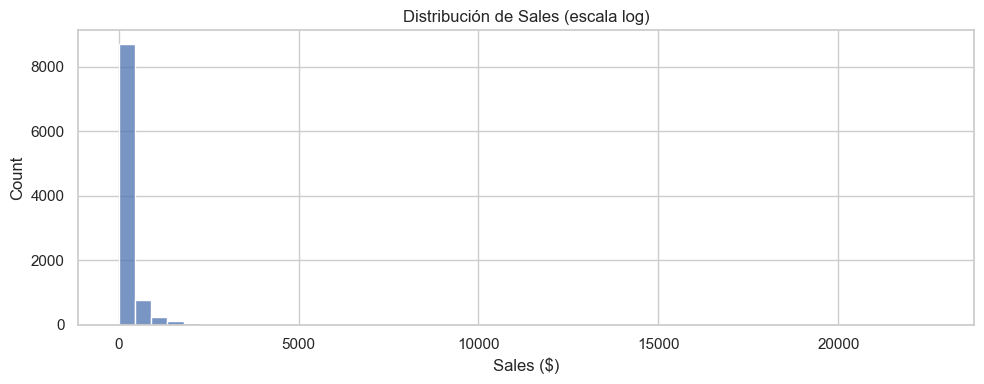

In [48]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Sales'], bins=50)
plt.title('Distribución de Sales (escala log)')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.show()

### 9.4 Distribución de Quantity → countplot

Aunque Quantity es numérica continua, en la práctica toma muy pocos valores únicos en el dataset (del 1 al 14). Usamos un countplot para ver la distribución con más claridad que un histograma.

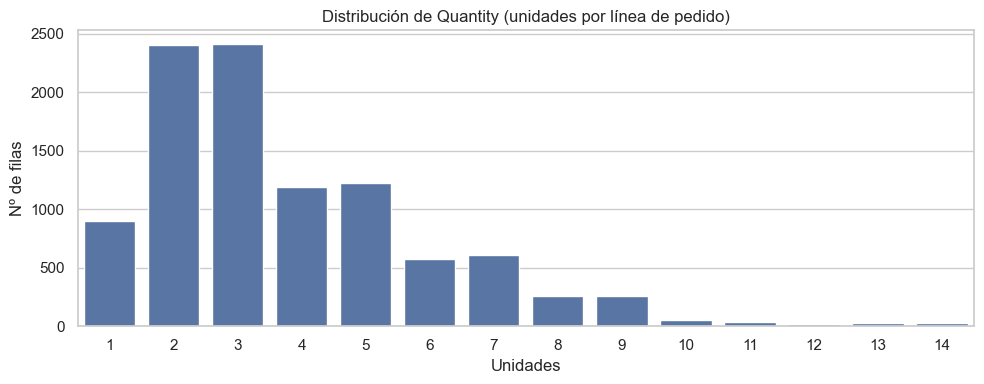

In [49]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Quantity')
plt.title('Distribución de Quantity (unidades por línea de pedido)')
plt.xlabel('Unidades')
plt.ylabel('Nº de filas')
plt.tight_layout()
plt.show()

### 9.5 Distribución de Discount → countplot

Discount es numérica discreta con solo 12 valores posibles (catálogo cerrado de descuentos). El countplot muestra cuántas ventas corresponden a cada tramo.

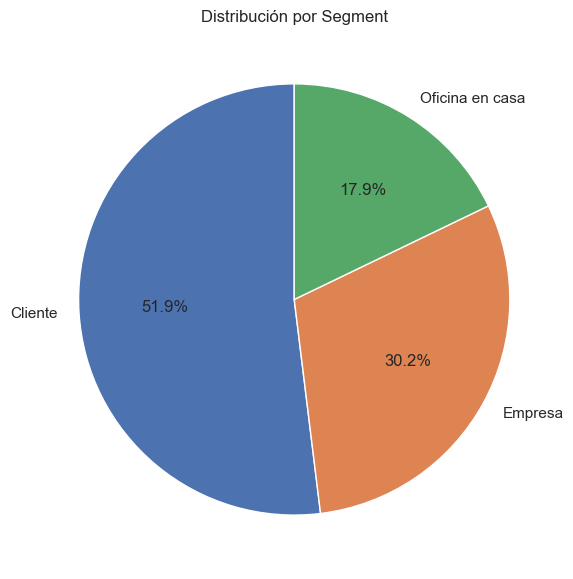

In [50]:
import matplotlib.pyplot as plt

segment_counts = df['Segment'].value_counts()

# PRUEBA DE ETIQUETAS NUEVAS
nuevas_labels = ['Cliente', 'Empresa', 'Oficina en casa']

plt.figure(figsize=(6, 6))
plt.pie(
segment_counts.values,
labels=nuevas_labels,
autopct='%1.1f%%',
startangle=90)

plt.title('Distribución por Segment')
plt.tight_layout()
plt.show()

### 9.6 Distribución de Profit → histograma con escala symlog

Profit tiene valores negativos (pérdidas) además de positivos, y su rango es enorme (-6.600 a +8.400). Usamos escala `symlog` que comprime los extremos pero permite valores negativos, a diferencia de la escala log pura. Calculamos los bins manualmente en escala logarítmica para que cada barra ocupe el espacio correcto en el eje (con `histplot` y bins automáticos las barras se apelotonarían cerca del 0).

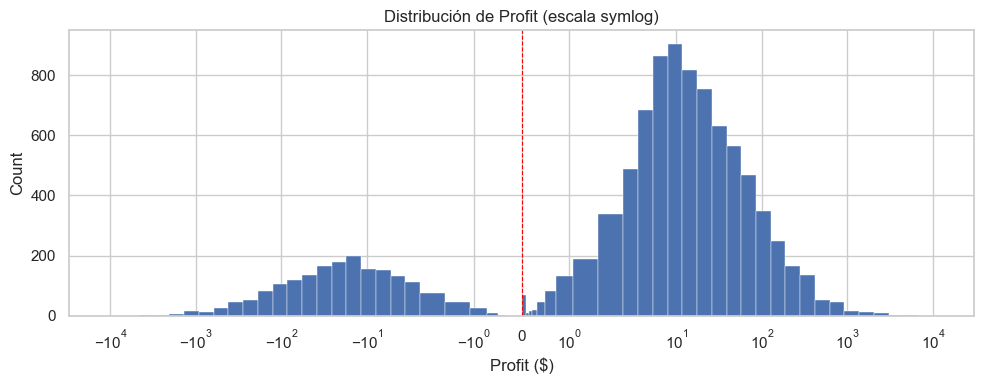

In [51]:
# Bins simétricos en escala log: cada bin ocupa una franja proporcional en el eje symlog
abs_max = max(abs(df['Profit'].min()), abs(df['Profit'].max()))
log_max = np.ceil(np.log10(abs_max))
positivos = np.logspace(-1, log_max, 30)
negativos = -positivos[::-1]
bins = np.concatenate([negativos, [0], positivos])

plt.figure(figsize=(10, 4))
plt.hist(df['Profit'], bins=bins, edgecolor='white', linewidth=0.3)
plt.xscale('symlog')
plt.axvline(0, color='red', linewidth=0.8, linestyle='--')
plt.title('Distribución de Profit (escala symlog)')
plt.xlabel('Profit ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 9.7 Serie temporal → ventas mensuales por Order Date

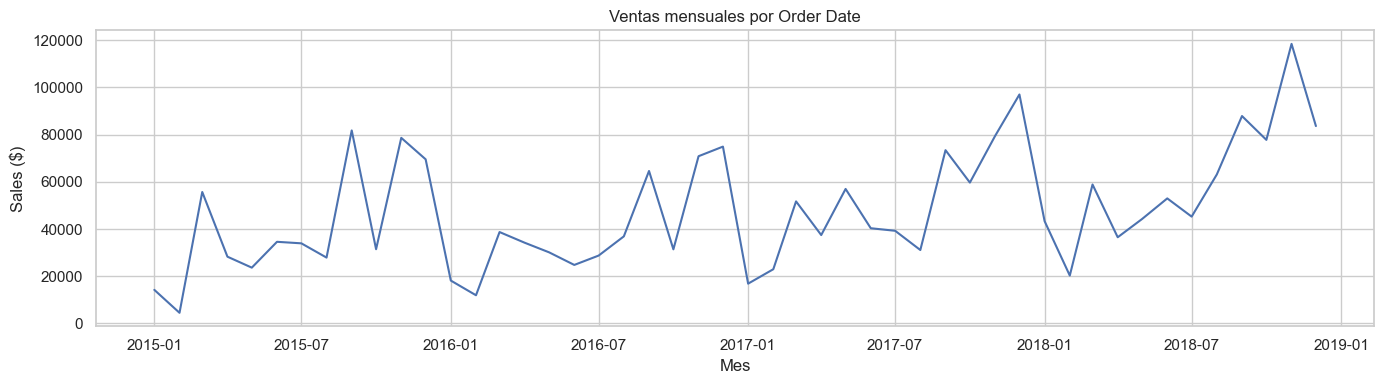

In [52]:
ventas_mensuales_ts = ventas_mensuales.copy()
ventas_mensuales_ts.index = ventas_mensuales_ts.index.to_timestamp()

plt.figure(figsize=(14, 4))
sns.lineplot(x=ventas_mensuales_ts.index, y=ventas_mensuales_ts.values)
plt.title('Ventas mensuales por Order Date')
plt.ylabel('Sales ($)')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

### 9.8 Días de envío por modalidad → boxplot

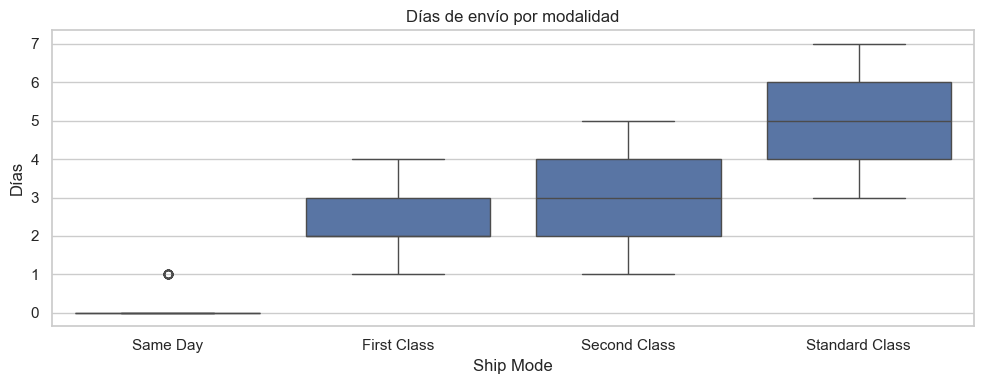

In [53]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=df,
    x='Ship Mode',
    y='Dias Envio',
    order=['Same Day', 'First Class', 'Second Class', 'Standard Class']
)
plt.title('Días de envío por modalidad')
plt.ylabel('Días')
plt.tight_layout()
plt.show()

## 10. Variables derivadas anuales

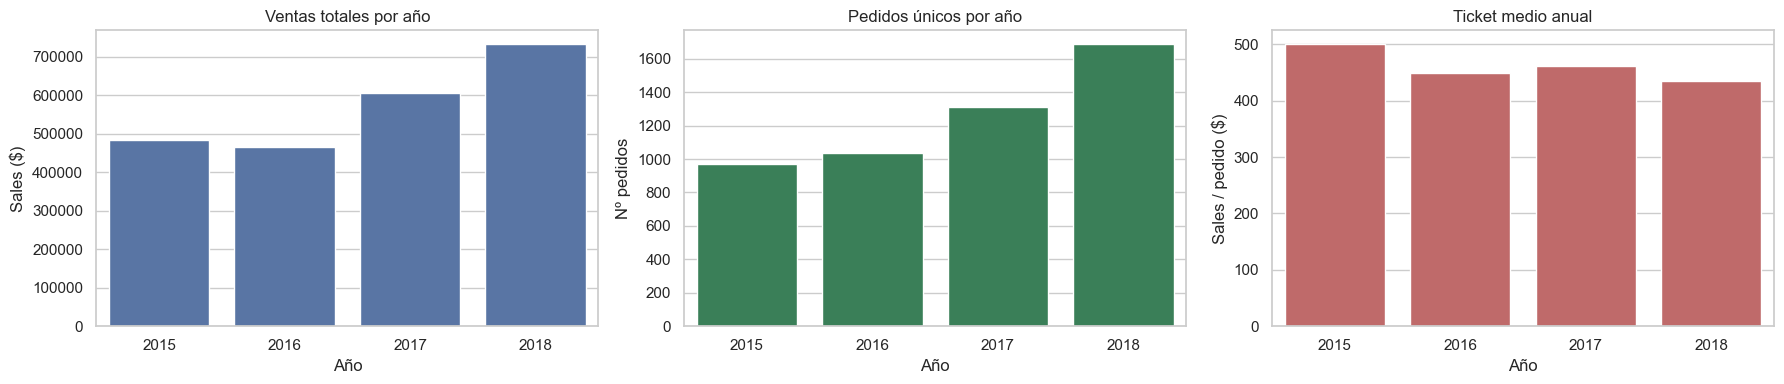

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(x=ventas_anuales.index, y=ventas_anuales.values, ax=axes[0])
axes[0].set_title('Ventas totales por año')
axes[0].set_ylabel('Sales ($)')
axes[0].set_xlabel('Año')

sns.barplot(x=pedidos_anuales.index, y=pedidos_anuales.values, ax=axes[1], color='seagreen')
axes[1].set_title('Pedidos únicos por año')
axes[1].set_ylabel('Nº pedidos')
axes[1].set_xlabel('Año')

sns.barplot(x=ticket_medio_anual.index, y=ticket_medio_anual.values, ax=axes[2], color='indianred')
axes[2].set_title('Ticket medio anual')
axes[2].set_ylabel('Sales / pedido ($)')
axes[2].set_xlabel('Año')

plt.tight_layout()
plt.show()

## 11. Productos: precio vs volumen

### 11.1 Top 15 productos con mayor precio medio de venta

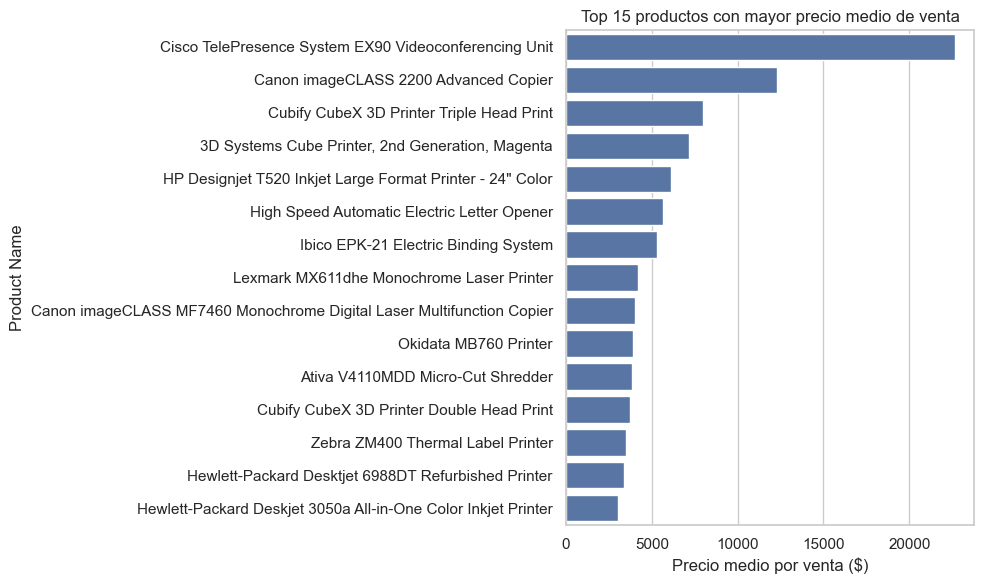

In [55]:
precio_medio = df.groupby('Product Name')['Sales'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=precio_medio.values, y=precio_medio.index)
plt.title('Top 15 productos con mayor precio medio de venta')
plt.xlabel('Precio medio por venta ($)')
plt.tight_layout()
plt.show()

### 11.2 Top 15 productos por ingresos totales

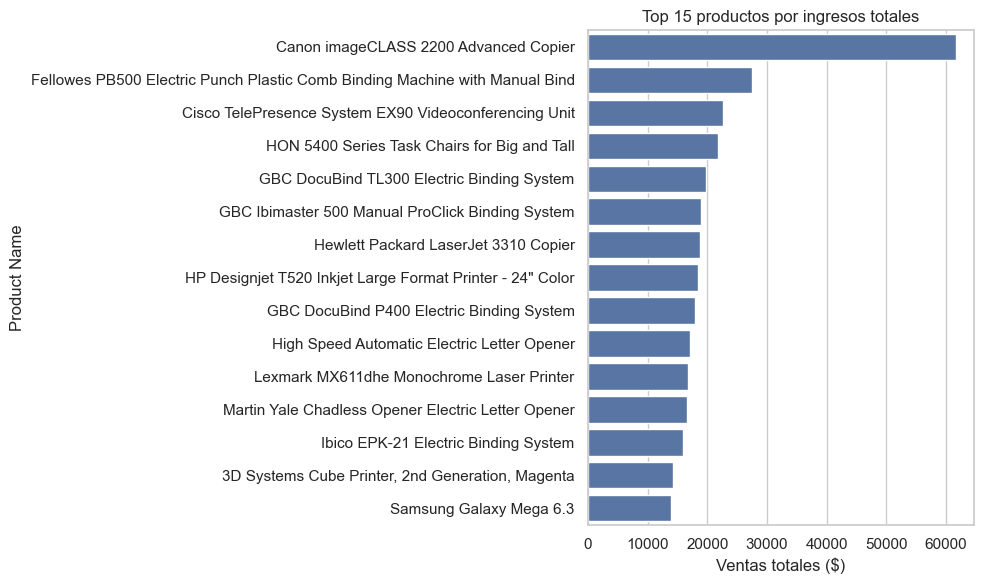

In [56]:
ingresos = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=ingresos.values, y=ingresos.index)
plt.title('Top 15 productos por ingresos totales')
plt.xlabel('Ventas totales ($)')
plt.tight_layout()
plt.show()

### 11.3 Precio medio por Sub-Category

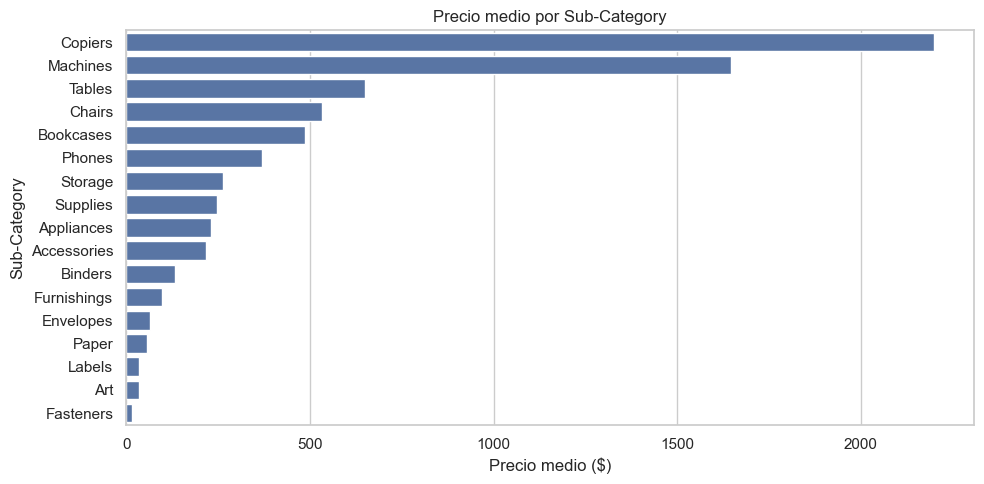

In [57]:
precio_por_subcat = df.groupby('Sub-Category')['Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=precio_por_subcat.values, y=precio_por_subcat.index)
plt.title('Precio medio por Sub-Category')
plt.xlabel('Precio medio ($)')
plt.tight_layout()
plt.show()

### 11.4 Scatterplot: volumen vs precio medio por Sub-Category

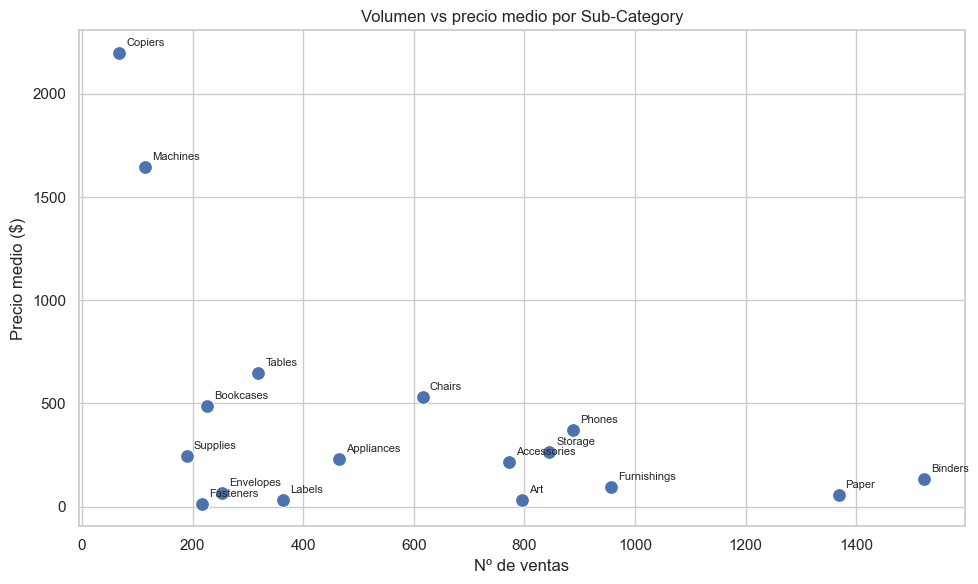

In [58]:
resumen = df.groupby('Sub-Category').agg(
    precio_medio=('Sales', 'mean'),
    n_ventas=('Sales', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=resumen, x='n_ventas', y='precio_medio', s=100)

for _, row in resumen.iterrows():
    plt.annotate(
        row['Sub-Category'],
        (row['n_ventas'], row['precio_medio']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('Volumen vs precio medio por Sub-Category')
plt.xlabel('Nº de ventas')
plt.ylabel('Precio medio ($)')
plt.tight_layout()
plt.show()

## 12. Análisis de rentabilidad

Usamos las columnas `Quantity`, `Discount` y `Profit` para responder preguntas que solo con `Sales` no se pueden contestar: qué productos dan dinero de verdad, qué descuentos son asumibles y cuáles destruyen el margen.

### 12.1 Profit total por Sub-Category

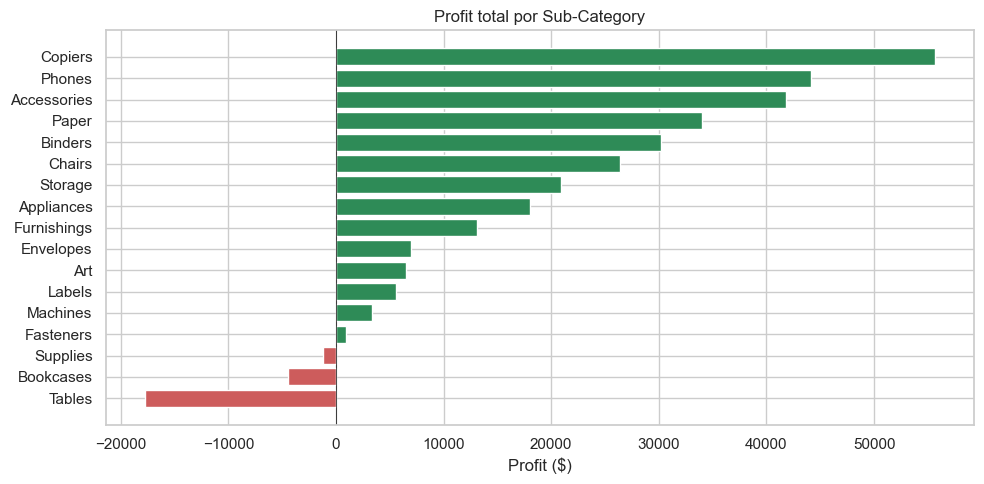

In [59]:
profit_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['seagreen' if v > 0 else 'indianred' for v in profit_subcat.values]
plt.barh(profit_subcat.index, profit_subcat.values, color=colors)
plt.gca().invert_yaxis()
plt.title('Profit total por Sub-Category')
plt.xlabel('Profit ($)')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 12.2 Facturación vs rentabilidad por Sub-Category

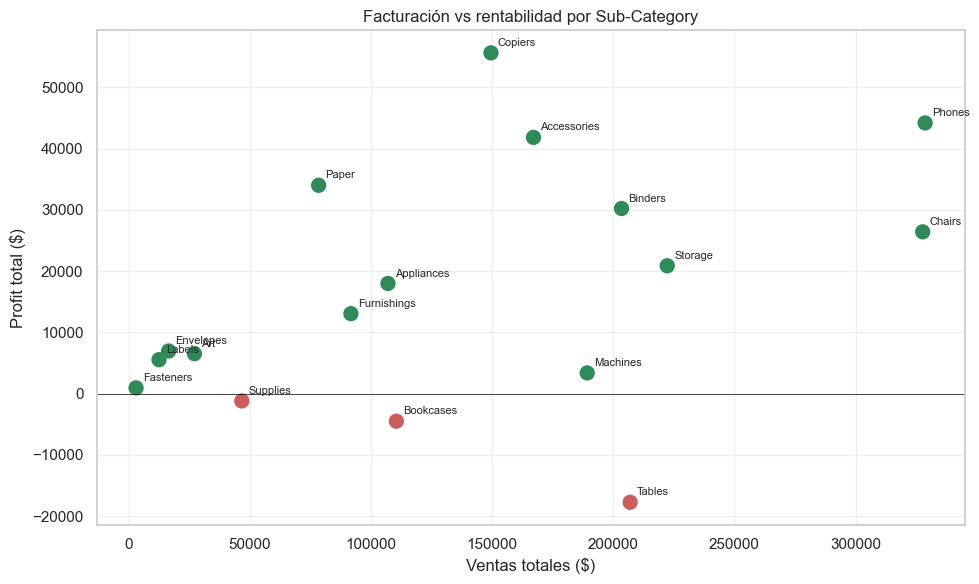

In [60]:
resumen_rent = df.groupby('Sub-Category').agg(
    sales=('Sales', 'sum'),
    profit=('Profit', 'sum')
).reset_index()

plt.figure(figsize=(10, 6))
colors = ['seagreen' if p > 0 else 'indianred' for p in resumen_rent['profit']]
plt.scatter(resumen_rent['sales'], resumen_rent['profit'], s=100, c=colors)

for _, row in resumen_rent.iterrows():
    plt.annotate(
        row['Sub-Category'],
        (row['sales'], row['profit']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.axhline(0, color='black', linewidth=0.5)
plt.title('Facturación vs rentabilidad por Sub-Category')
plt.xlabel('Ventas totales ($)')
plt.ylabel('Profit total ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 12.3 Relación descuento vs rentabilidad

                   mean        sum  count
Tramo Descuento                          
0%                66.59  318742.62   4787
1-10%             96.06    9029.18     94
10-20%            24.74   91756.30   3709
20-30%           -45.68  -10369.28    227
30-50%          -156.28  -48447.73    310
50-80%           -89.44  -76559.05    856


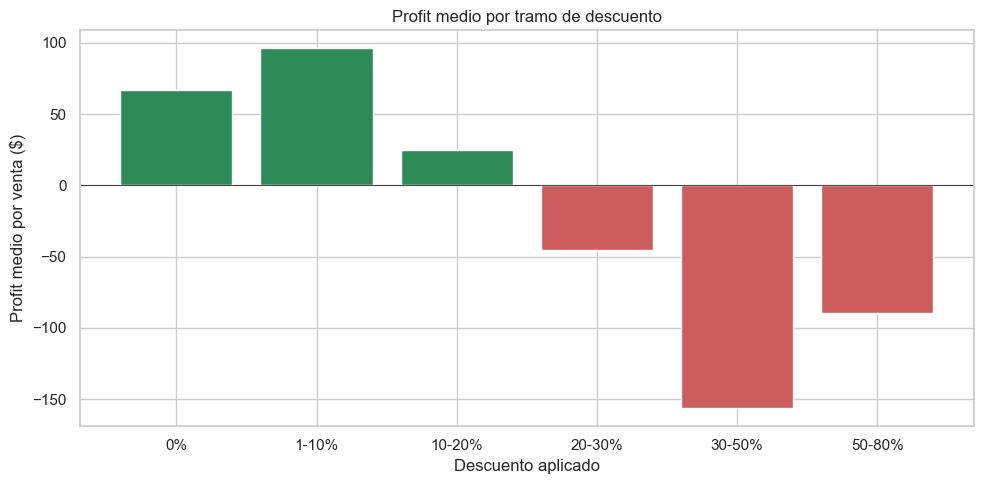

In [61]:
# Agrupamos por tramos de descuento y vemos el profit medio en cada tramo
bins = [-0.01, 0.01, 0.1, 0.2, 0.3, 0.5, 0.8]
labels = ['0%', '1-10%', '10-20%', '20-30%', '30-50%', '50-80%']
df['Tramo Descuento'] = pd.cut(df['Discount'], bins=bins, labels=labels)

profit_por_descuento = df.groupby('Tramo Descuento', observed=True)['Profit'].agg(['mean', 'sum', 'count'])
print(profit_por_descuento.round(2))

plt.figure(figsize=(10, 5))
colors = ['seagreen' if v > 0 else 'indianred' for v in profit_por_descuento['mean']]
plt.bar(profit_por_descuento.index.astype(str), profit_por_descuento['mean'], color=colors)
plt.title('Profit medio por tramo de descuento')
plt.ylabel('Profit medio por venta ($)')
plt.xlabel('Descuento aplicado')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 12.4 Top 10 productos más rentables y menos rentables

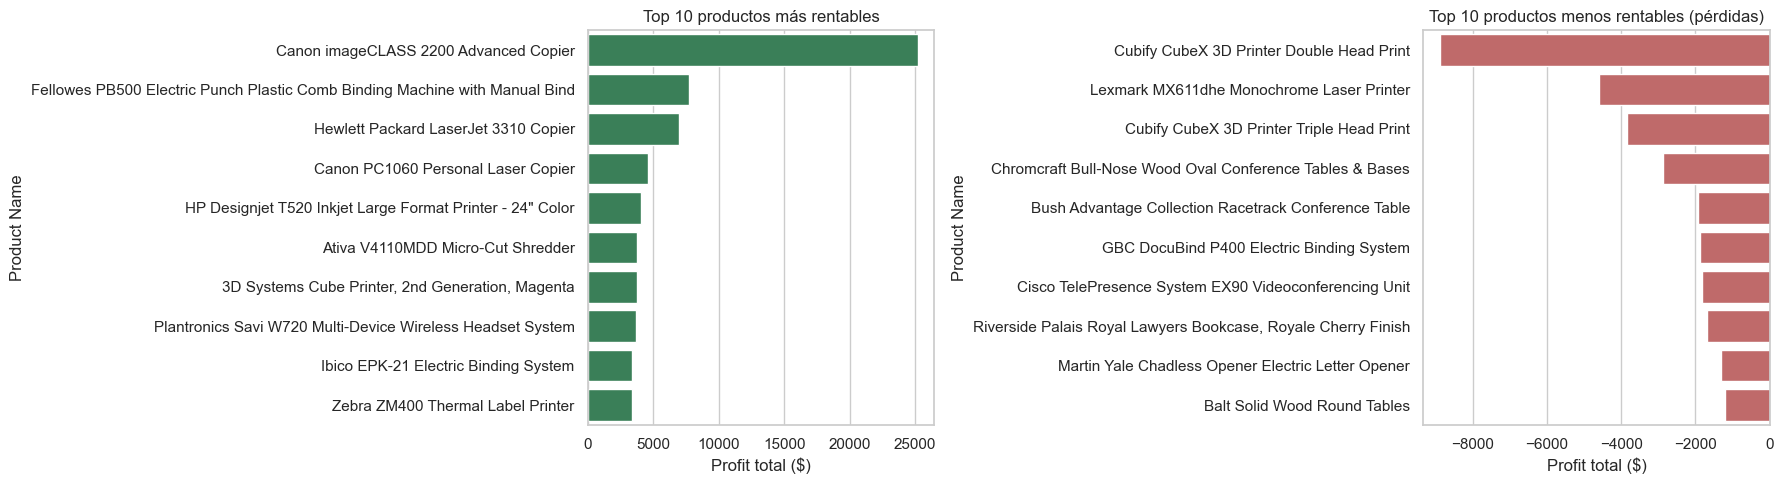

In [62]:
profit_producto = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)

top_10 = profit_producto.head(10)
bottom_10 = profit_producto.tail(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.barplot(x=top_10.values, y=top_10.index, ax=axes[0], color='seagreen')
axes[0].set_title('Top 10 productos más rentables')
axes[0].set_xlabel('Profit total ($)')

sns.barplot(x=bottom_10.values, y=bottom_10.index, ax=axes[1], color='indianred')
axes[1].set_title('Top 10 productos menos rentables (pérdidas)')
axes[1].set_xlabel('Profit total ($)')

plt.tight_layout()
plt.show()

### 12.5 Distribución del margen porcentual por nivel de descuento → boxplot

En vez de graficar `Profit` absoluto (en dólares), usamos el **margen porcentual** (`Profit / Sales × 100`). Razón: un descuento alto puede generar una pérdida pequeña en dólares si el producto es barato, y eso distorsiona la lectura visual del `Profit` absoluto. El margen porcentual normaliza todas las ventas a una escala común — lo que importa no es cuánto se pierde en euros, sino qué fracción del precio de venta se destruye.

Con margen porcentual, el descenso es monótono: a más descuento, más destrucción de valor relativo. No hay trampa visual.

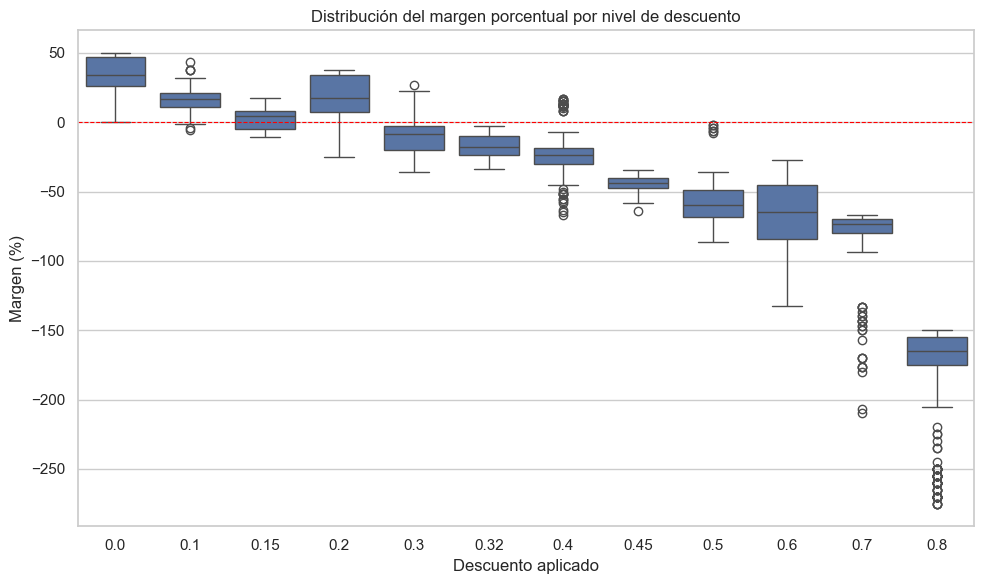

In [63]:
# Calculamos margen porcentual por línea de venta
df['Margen'] = df['Profit'] / df['Sales'] * 100

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Discount', y='Margen')
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')
plt.title('Distribución del margen porcentual por nivel de descuento')
plt.xlabel('Descuento aplicado')
plt.ylabel('Margen (%)')
plt.tight_layout()
plt.show()

### 16. Relplot , relación entre Código postal y ventas


Relplot entre Descuento y Ventas
Se ve como hay pedidos grandes sin oferta y pedidos muy grandes con mucha oferta. 
El descuento parece usarse como herramienta puntual, en el que a veces se descuenta mucho apra pedidos grandes pero otras veces se consiguen ventas grandes sin tocar el precio.

Usando x = 'Discount' y y = 'Sales'


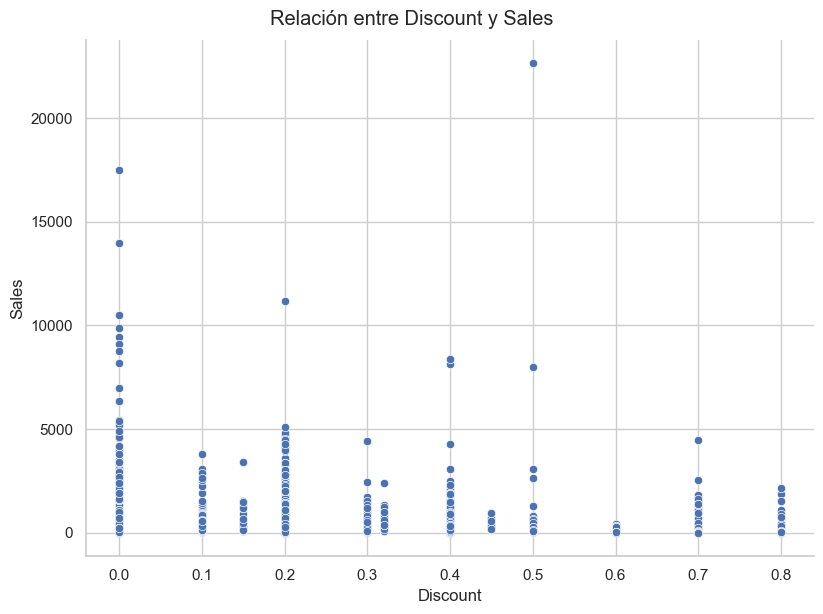

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

x_col = 'Discount' # cp
y_col = 'Sales' #ventas

print(f"Usando x = '{x_col}' y y = '{y_col}'")

g = sns.relplot(
data=df,
x=x_col,
y=y_col,
kind='scatter',
height=6,
aspect=1.4)

#la g sola es una variable sin mas, y fig aparece tachado como que no lo reconoce, pero sí funciona.
g.fig.suptitle(f"Relación entre {x_col} y {y_col}", y=1.02)
plt.show()

# lo que se ve: 
# Eje X son descuento numéricos, y el eje y , las ventas
# Cada punto es una línea de pedido.